# Entrenamiento y Optimización de hiperparametros

Señales vistas en el EDA:
- Tamaño del dataset: Tenemos un dataset con pocos datos (5.1k) lo cual favorece a modelos simples e interpretables (KNN)
- Número de features: tenemos un bajo numero de features, por lo que también favorece modelos de menor complejidad.
- Dataset altamente desbalanceado: preferimos modelos que soporten nativamente `class_weights`. SMOTE (SMOTENC especificamente) genera pacientes sintéticos interpolando los datos reales, no nos pareció entrenar modelos con 'pacientes sintéticos'. Sabemos que los modelos aprenden fronteras de decisión, no memorizar pacientes, pero en este contexto preferimos mantener los datos reales.
- Necesidad de intrepretabilidad, como arboles simples


### Baseline
- Age Classifier como baseline: debido a la fuerte correlacion entre stroke con la variable AGE optamos por predecir clase positiva para AGE > 50.

### Elegimos los siguientes modelos:

- KNN: Un modelo basado en distancia podria funcionar en nuestro dataset ya que es lo suficientemente pequeño para que sea viable computacionalmente. Permite explorar si la similitud entre pacientes en el espacio de features (edad, glucosa, bmi) es suficiente para distinguir casos de stroke. Sin embargo, un fuerte desbalance afectará la performance del modelo.

- Decision Tree (Arbol simple): el riesgo de stroke tiene relaciones no lineales con features como la edad, glucosa y bmi, un arbol puede capturar con particiones simples estos casos. Además, ofrece un buen grado de interpretabilidad.

- Random Forest (Ensamble bagging): Es esperado que un solo arbol tiende a overfit, algo que random forest mitigaría.

- XGBoost (Ensamble Boosting): mientras que random forest promedia arboles, con este modelo se corregirian errores iterativamente,.
  
- SVC: busca el hiperplano de maximo margen entre clases. Al usar un kernel polinomial o radial puede capturar fronteras de decision no lineales, lo que lo hace relevante segun lo visto en el EDA.

Contexto **médico** (predicción de stroke) con clases altamente desbalanceadas (~19.5:1). Un **falso negativo**, es decir no detectar un stroke para alguien que si esta en riesgo es un error catastrófico, mientras que un falso positivo, aunque indeseable, tiene consecuencias mucho menores.

Usamos **F-beta score** (β=2): Recall pesa ~4× más que Precision, priorizando que el modelo no se pierda casos reales de stroke. A diferencia del **recall** puro, el f-beta sigue penalizando en modelos que predicen 'stroke' para todos, manteniendo un grado de robustez en precision.

Para ajustar el peso de Recall, cambiar `BETA` en la celda de setup.

In [205]:
import os
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import optuna

from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_validate
from sklearn.metrics import (
    make_scorer, fbeta_score,
    roc_auc_score, average_precision_score,
    f1_score, recall_score, precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay,
)

import warnings
warnings.filterwarnings('ignore')

# El nb01 genera 3 splits: train / val / test.
#  - X_train: CV 5-fold para tuning de hiperparámetros.
#  - X_val:   comparación de los modelos tuneados para elegir al ganador post-tuning.
#  - X_test:  evaluación final del modelo ganador (holdout intocado, se usa en nb05).
data = joblib.load('../data/processed_data.pkl')
X_train = data['X_train']
X_test  = data['X_test']
X_val   = data['X_val']
y_train = data['y_train']
y_test  = data['y_test']
y_val   = data['y_val']

print(f'X_train: {X_train.shape} | X_test: {X_test.shape} | X_val: {X_val.shape}')
print(f'Distribución de clases (train): {np.bincount(y_train.astype(int))}')
print(f'Ratio de desbalance: {np.sum(y_train==0)/np.sum(y_train==1):.1f}:1')

X_train: (3065, 14) | X_test: (1022, 14) | X_val: (1022, 14)
Distribución de clases (train): [2916  149]
Ratio de desbalance: 19.6:1


## Setup 

En esta celda se setea: el scorer F-beta, la CV estratificada 5-fold, `scale_pos_weight` para XGBoost, y un helper `cv_f2` que evalúa un modelo con CV=5 y devuelve el F-beta medio (lo que cada `objective` de Optuna maximiza).

Tenemos una validacion cruzada de 5 folds

**Por qué Optuna?:** Optuna con `TPESampler` (Tree-structured Parzen Estimator) hace búsqueda bayesiana — aprende de los trials previos y converge más rápido que random search o gridsearch, especialmente en espacios con parámetros continuos (`learning_rate`, `subsample`, `colsample_bytree`).

In [206]:
BETA = 2  # para podrr ajustar el f-score. Hay que reentrenar cada vez que se cambia
METRIC_NAME = f'F{BETA}'  # se usa como clave de métricas en dicts/tablas
f2_scorer = make_scorer(fbeta_score, beta=BETA)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# scale_pos_weight para XGBoost (no tiene `class_weight`)
neg, pos = np.bincount(y_train)
scale_pos = neg / pos

# Dict de métricas para reporting en la tabla comparativa
scoring = {
    METRIC_NAME: f2_scorer,
    'Recall':    'recall',
    'Precision': 'precision',
    'ROC_AUC':   'roc_auc',
    'PR_AUC':    'average_precision',
}

# Silenciar logs verbosos de Optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

# Helper: evalúa un modelo con CV=5 y devuelve F-beta medio (lo que cada objective maximiza)
def cv_f2(model, X, y):
    return cross_val_score(model, X, y, cv=cv, scoring=f2_scorer, n_jobs=-1).mean()

# Helper: imprime todas las métricas relevantes del mejor modelo en CV
def print_cv_metrics(name, model):
    s = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    print(f'\nMétricas CV — {name}:')
    for metric, key in [
        (METRIC_NAME,  f"test_{METRIC_NAME}"),
        ('Recall',     'test_Recall'),
        ('Precision',  'test_Precision'),
        ('ROC-AUC',    'test_ROC_AUC'),
        ('PR-AUC',     'test_PR_AUC'),
    ]:
        print(f'  {metric:<12} {s[key].mean():.4f}')

## Baseline

In [207]:
print(f"feature en índice 0: '{data['feature_names'][0]}'")
print(f"X_val[:, 0] primeros 10 valores: {X_val[:10, 0]}")

feature en índice 0: 'age'
X_val[:, 0] primeros 10 valores: [-1.6140959   1.69153998 -0.00594872  0.44075884 -0.22930249  0.08339279
  0.08339279 -1.86067847  0.93213714 -0.13996098]


Se elige un baseline sencillo que predice stroke de acuerdo a la edad. Se vio en el EDA que la mayoría de strokes ocurren en pacientes con age > 50.

In [208]:
from scipy.special import expit

class AgeBaselineClassifier(BaseEstimator, ClassifierMixin):
    def __init__(self, threshold=0):
        self.threshold = threshold

    def fit(self, X, y=None):
        self.classes_ = np.array([0, 1])
        return self

    def predict(self, X):
        return (X[:, 0] > self.threshold).astype(int)

    def predict_proba(self, X):
        # Score continuo = edad estandarizada mapeada a [0, 1] con sigmoide.
        # Preserva el ranking por edad para que AUC-ROC y PR-AUC midan
        # de verdad qué tan bien la edad sola separa las clases.
        p1 = expit(X[:, 0])
        return np.column_stack([1 - p1, p1])

baseline_model = AgeBaselineClassifier(threshold=0.3)

y_pred_baseline_val = baseline_model.predict(X_val)
y_prob_baseline_val = baseline_model.predict_proba(X_val)[:, 1]

bl_metrics = {
    'Modelo':    'Baseline',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_baseline_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_baseline_val),
    'F1':        f1_score(y_val, y_pred_baseline_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_baseline_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_baseline_val),
    'Precision': precision_score(y_val, y_pred_baseline_val, zero_division=0),
}
print(bl_metrics)

{'Modelo': 'Baseline', 'AUC-ROC': 0.7920473251028807, 'PR-AUC': 0.15584636493160633, 'F1': 0.1670061099796334, 'F2': 0.31981279251170047, 'Recall': 0.82, 'Precision': 0.09297052154195011}


El baseline es fuerte y se confirma lo visto en el EDA, la edad es el predictor más fuerte.
- AUC-ROC= 0.79: rankear pacientes solo por edad ya separa razonablemente bien las clases.

- Recall = 0.82: se capturan el 82% de los strokes reales solo viendo si el paciente tiene más de 50 años.

Pero también muestra los límites de un baseline simple:
- Precisión = 0.09: muchos falsos positivos. El baseline genera mucho ruido.

- PR-AUC = 0.16: Solamente la edad no alcanza para separar bien a los positivos de los negativos, se necesitan features adicionales.

Este baseline queda como la linea a superar por los modelos.

## KNN

Espacio de búsqueda: número de vecinos, tipo de peso y métrica (`p=1` Manhattan, `p=2` Euclidiana). Knn no necesita class_weight pues en teoria no lo necesita.

In [209]:
def knn_objective(trial):
    params = {
        'n_neighbors': trial.suggest_int('n_neighbors', 3, 30),
        'weights':     trial.suggest_categorical('weights', ['uniform', 'distance']),
        'p':           trial.suggest_categorical('p', [1, 2]),
    }
    model = KNeighborsClassifier(n_jobs=-1, **params)
    return cv_f2(model, X_train, y_train)

knn_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
knn_study.optimize(knn_objective, n_trials=50, show_progress_bar=True)

knn_best_params = knn_study.best_params
knn_best = KNeighborsClassifier(n_jobs=-1, **knn_best_params).fit(X_train, y_train)

print('Mejores parámetros (KNN):')
for k, v in knn_best_params.items():
    print(f'  {k}: {v}')

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (KNN):
  n_neighbors: 4
  weights: distance
  p: 1


In [210]:
print_cv_metrics('KNN', knn_best)


Métricas CV — KNN:
  F2           0.0773
  Recall       0.0674
  Precision    0.2000
  ROC-AUC      0.6463
  PR-AUC       0.1161


## Decision Tree

Espacio de búsqueda: profundidad, criterio de split y regularización (`min_samples_*`).

In [211]:
def dt_objective(trial):
    params = {
        'max_depth':         trial.suggest_int('max_depth', 3, 20),
        'min_samples_leaf':  trial.suggest_int('min_samples_leaf', 1, 50),
        'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
        'criterion':         trial.suggest_categorical('criterion', ['gini', 'entropy']),
    }
    model = DecisionTreeClassifier(class_weight='balanced', random_state=42, **params)
    return cv_f2(model, X_train, y_train)

dt_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
dt_study.optimize(dt_objective, n_trials=50, show_progress_bar=True)

dt_best_params = dt_study.best_params
dt_best = DecisionTreeClassifier(
    class_weight='balanced', random_state=42, **dt_best_params
).fit(X_train, y_train)

print('Mejores parámetros (Decision Tree):')
for k, v in dt_best_params.items():
    print(f'  {k}: {v}')
print_cv_metrics('Decision Tree', dt_best)

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (Decision Tree):
  max_depth: 15
  min_samples_leaf: 43
  min_samples_split: 18
  criterion: gini

Métricas CV — Decision Tree:
  F2           0.4003
  Recall       0.8057
  Precision    0.1341
  ROC-AUC      0.7782
  PR-AUC       0.1381


## Random Forest

Espacio de búsqueda: número de árboles, profundidad, regularización y muestreo de features.

In [212]:
def rf_objective(trial):
    params = {
        'n_estimators':     trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
        'max_depth':        trial.suggest_categorical('max_depth', [5, 10, 15, 20, None]),
        'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
        'max_features':     trial.suggest_categorical('max_features', ['sqrt', 'log2', 0.5]),
    }
    model = RandomForestClassifier(
        class_weight='balanced', random_state=42, n_jobs=-1, **params
    )
    return cv_f2(model, X_train, y_train)

rf_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
rf_study.optimize(rf_objective, n_trials=50, show_progress_bar=True)

rf_best_params = rf_study.best_params
rf_best = RandomForestClassifier(
    class_weight='balanced', random_state=42, n_jobs=-1, **rf_best_params
).fit(X_train, y_train)

print('Mejores parámetros (Random Forest):')
for k, v in rf_best_params.items():
    print(f'  {k}: {v}')
print_cv_metrics('Random Forest', rf_best)

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (Random Forest):
  n_estimators: 100
  max_depth: 10
  min_samples_leaf: 19
  max_features: log2

Métricas CV — Random Forest:
  F2           0.4092
  Recall       0.7182
  Precision    0.1505
  ROC-AUC      0.8426
  PR-AUC       0.1862


## XGBoost

Espacio de búsqueda más rico: learning rate, subsampling de filas y columnas, `min_child_weight`

In [213]:
def xgb_objective(trial):
    params = {
        'n_estimators':     trial.suggest_categorical('n_estimators', [100, 200, 300, 500]),
        'max_depth':        trial.suggest_int('max_depth', 3, 10),
        'learning_rate':    trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'subsample':        trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
    }
    model = XGBClassifier(
        scale_pos_weight=scale_pos,
        eval_metric='aucpr',
        random_state=42,
        use_label_encoder=False,
        n_jobs=1,
        **params,
    )
    return cv_f2(model, X_train, y_train)

xgb_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
xgb_study.optimize(xgb_objective, n_trials=50, show_progress_bar=True)

xgb_best_params = xgb_study.best_params
xgb_best = XGBClassifier(
    scale_pos_weight=scale_pos,
    eval_metric='aucpr',
    random_state=42,
    use_label_encoder=False,
    n_jobs=1,
    **xgb_best_params,
).fit(X_train, y_train)

print('Mejores parámetros (XGBoost):')
for k, v in xgb_best_params.items():
    print(f'  {k}: {v}')
print_cv_metrics('XGBoost', xgb_best)

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (XGBoost):
  n_estimators: 200
  max_depth: 3
  learning_rate: 0.05508629584267081
  min_child_weight: 5
  subsample: 0.7143519737735834
  colsample_bytree: 0.8839578671825332

Métricas CV — XGBoost:
  F2           0.4166
  Recall       0.6986
  Precision    0.1597
  ROC-AUC      0.8389
  PR-AUC       0.1935


## SVC

Espacio de búsqueda con 4 kernels (linear/rbf/poly/sigmoid). Se usa `class_weight='balanced'` y `probability=True` para poder calcular AUC-ROC y PR-AUC. El parámetro `C` y `gamma` dependen del kernel (espacios condicionales).



In [214]:
def svc_objective(trial):
    kernel = trial.suggest_categorical('kernel', ['linear', 'rbf', 'poly', 'sigmoid'])

    if kernel == 'linear':
        params = {
            'kernel': kernel,
            'C': trial.suggest_float('C_linear', 1e-3, 1e2, log=True),
        }
    elif kernel == 'rbf':
        params = {
            'kernel': kernel,
            'C':     trial.suggest_float('C_rbf', 1e-2, 1e2, log=True),
            'gamma': trial.suggest_categorical('gamma_rbf',
                ['scale', 'auto', 0.001, 0.005, 0.01, 0.05, 0.1]),
        }
    elif kernel == 'poly':
        params = {
            'kernel': kernel,
            'C':      trial.suggest_categorical('C_poly', [0.1, 1.0, 10.0]),
            'degree': trial.suggest_int('degree', 2, 4),
            'gamma':  trial.suggest_categorical('gamma_poly', ['scale', 'auto']),
        }
    else:  # sigmoid
        params = {
            'kernel': kernel,
            'C':     trial.suggest_categorical('C_sig', [0.1, 1.0, 10.0]),
            'gamma': trial.suggest_categorical('gamma_sig', ['scale', 'auto']),
        }

    model = SVC(
        class_weight='balanced',
        probability=True,
        random_state=42,
        **params,
    )
    return cv_f2(model, X_train, y_train)


def build_svc_from_params(best_params):
    kernel = best_params['kernel']
    build = dict(kernel=kernel, class_weight='balanced', probability=True, random_state=42)
    if kernel == 'linear':
        build['C'] = best_params['C_linear']
    elif kernel == 'rbf':
        build['C']     = best_params['C_rbf']
        build['gamma'] = best_params['gamma_rbf']
    elif kernel == 'poly':
        build['C']      = best_params['C_poly']
        build['degree'] = best_params['degree']
        build['gamma']  = best_params['gamma_poly']
    else:  # sigmoid
        build['C']     = best_params['C_sig']
        build['gamma'] = best_params['gamma_sig']
    return SVC(**build)


svc_study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
svc_study.optimize(svc_objective, n_trials=50, show_progress_bar=True)

svc_best_params = svc_study.best_params
svc_best = build_svc_from_params(svc_best_params).fit(X_train, y_train)

print('Mejores parámetros (SVC):')
for k, v in svc_best_params.items():
    print(f'  {k}: {v}')
print_cv_metrics('SVC', svc_best)

  0%|          | 0/50 [00:00<?, ?it/s]

Mejores parámetros (SVC):
  kernel: poly
  C_poly: 0.1
  degree: 2
  gamma_poly: scale

Métricas CV — SVC:
  F2           0.4097
  Recall       0.7924
  Precision    0.1398
  ROC-AUC      0.8444
  PR-AUC       0.1999


## Resumen de Cross-Validation

Tabla con las métricas CV de la mejor configuración de cada modelo. La columna F-beta es la que se usó para seleccionar.

In [215]:
def cv_row(name, model):
    scores = cross_validate(model, X_train, y_train, cv=cv, scoring=scoring, n_jobs=-1)
    return {
        'Modelo':    name,
        METRIC_NAME: scores[f'test_{METRIC_NAME}'].mean(),
        'Recall':    scores[f'test_Recall'].mean(),
        'Precision': scores[f'test_Precision'].mean(),
        'ROC-AUC':   scores[f'test_ROC_AUC'].mean(),
        'PR-AUC':    scores[f'test_PR_AUC'].mean(),
    }

cv_summary = (
    pd.DataFrame([
        cv_row('KNN',              knn_best),
        cv_row('Decision Tree',    dt_best),
        cv_row('Random Forest',    rf_best),
        cv_row('XGBoost',          xgb_best),
        cv_row('SVC',              svc_best),
    ])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(cv_summary.style.highlight_max(axis=0).format('{:.4f}'))

,F2,Recall,Precision,ROC-AUC,PR-AUC
Modelo,,,,,
XGBoost,0.4166,0.6986,0.1597,0.8389,0.1935
SVC,0.4097,0.7924,0.1398,0.8444,0.1999
Random Forest,0.4092,0.7182,0.1505,0.8426,0.1862
Decision Tree,0.4003,0.8057,0.1341,0.7782,0.1381
KNN,0.0773,0.0674,0.2000,0.6463,0.1161


Como era de esperarse, la precisión resulta baja en todos los modelos. Tenemos un desbalance extremo y además que estamos priorizando recall

## Comparación en Validation 

Veamos las métricas sobre `X_val`


In [216]:
# Decision Tree
y_prob_dt_val = dt_best.predict_proba(X_val)[:, 1]
y_pred_dt_val = dt_best.predict(X_val)

dt_metrics = {
    'Modelo':    'Decision Tree',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_dt_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_dt_val),
    'F1':        f1_score(y_val, y_pred_dt_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_dt_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_dt_val),
    'Precision': precision_score(y_val, y_pred_dt_val, zero_division=0),
}
print(dt_metrics)


{'Modelo': 'Decision Tree', 'AUC-ROC': 0.7680349794238683, 'PR-AUC': 0.14339518399928292, 'F1': 0.23225806451612904, 'F2': 0.391304347826087, 'Recall': 0.72, 'Precision': 0.13846153846153847}


In [217]:
# Random Forest
y_prob_rf_val = rf_best.predict_proba(X_val)[:, 1]
y_pred_rf_val = rf_best.predict(X_val)

rf_metrics = {
    'Modelo':    'Random Forest',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_rf_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_rf_val),
    'F1':        f1_score(y_val, y_pred_rf_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_rf_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_rf_val),
    'Precision': precision_score(y_val, y_pred_rf_val, zero_division=0),
}
print(rf_metrics)


{'Modelo': 'Random Forest', 'AUC-ROC': 0.8070576131687243, 'PR-AUC': 0.25892556499972935, 'F1': 0.24584717607973422, 'F2': 0.41019955654101997, 'Recall': 0.74, 'Precision': 0.14741035856573706}


In [218]:
# XGBoost
y_prob_xgb_val = xgb_best.predict_proba(X_val)[:, 1]
y_pred_xgb_val = xgb_best.predict(X_val)

xgb_metrics = {
    'Modelo':    'XGBoost',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_xgb_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_xgb_val),
    'F1':        f1_score(y_val, y_pred_xgb_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_xgb_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_xgb_val),
    'Precision': precision_score(y_val, y_pred_xgb_val, zero_division=0),
}
print(xgb_metrics)


{'Modelo': 'XGBoost', 'AUC-ROC': 0.8024176954732509, 'PR-AUC': 0.22888650993147436, 'F1': 0.23102310231023102, 'F2': 0.38631346578366443, 'Recall': 0.7, 'Precision': 0.1383399209486166}


In [219]:
# KNN
y_prob_knn_val = knn_best.predict_proba(X_val)[:, 1]
y_pred_knn_val = knn_best.predict(X_val)

knn_metrics = {
    'Modelo':    'KNN',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_knn_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_knn_val),
    'F1':        f1_score(y_val, y_pred_knn_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_knn_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_knn_val),
    'Precision': precision_score(y_val, y_pred_knn_val, zero_division=0),
}
print(knn_metrics)


{'Modelo': 'KNN', 'AUC-ROC': 0.640812757201646, 'PR-AUC': 0.08433712804413057, 'F1': 0.058823529411764705, 'F2': 0.045871559633027525, 'Recall': 0.04, 'Precision': 0.1111111111111111}


In [220]:
# SVC
y_prob_svc_val = svc_best.predict_proba(X_val)[:, 1]
y_pred_svc_val = svc_best.predict(X_val)

svc_metrics = {
    'Modelo':    'SVC',
    'AUC-ROC':   roc_auc_score(y_val, y_prob_svc_val),
    'PR-AUC':    average_precision_score(y_val, y_prob_svc_val),
    'F1':        f1_score(y_val, y_pred_svc_val),
    METRIC_NAME: fbeta_score(y_val, y_pred_svc_val, beta=BETA),
    'Recall':    recall_score(y_val, y_pred_svc_val),
    'Precision': precision_score(y_val, y_pred_svc_val, zero_division=0),
}
print(svc_metrics)


{'Modelo': 'SVC', 'AUC-ROC': 0.7926543209876544, 'PR-AUC': 0.18768029492820726, 'F1': 0.2140845070422535, 'F2': 0.37623762376237624, 'Recall': 0.76, 'Precision': 0.12459016393442623}


In [221]:
val_df = (
    pd.DataFrame([
        knn_metrics, dt_metrics, rf_metrics, xgb_metrics, svc_metrics, bl_metrics
    ])
    .set_index('Modelo')
    .sort_values(METRIC_NAME, ascending=False)
)
display(val_df.style.highlight_max(axis=0).format('{:.4f}'))

best_model_name = val_df[METRIC_NAME].idxmax()
print(f'\nMejor modelo por {METRIC_NAME} en val: {best_model_name} '
      f'({METRIC_NAME}={val_df.loc[best_model_name, METRIC_NAME]:.4f}, '
      f'Recall={val_df.loc[best_model_name, "Recall"]:.4f})')

,AUC-ROC,PR-AUC,F1,F2,Recall,Precision
Modelo,,,,,,
Random Forest,0.8071,0.2589,0.2458,0.4102,0.7400,0.1474
Decision Tree,0.7680,0.1434,0.2323,0.3913,0.7200,0.1385
XGBoost,0.8024,0.2289,0.2310,0.3863,0.7000,0.1383
SVC,0.7927,0.1877,0.2141,0.3762,0.7600,0.1246
Baseline,0.7920,0.1558,0.1670,0.3198,0.8200,0.0930
KNN,0.6408,0.0843,0.0588,0.0459,0.0400,0.1111



Mejor modelo por F2 en val: Random Forest (F2=0.4102, Recall=0.7400)


## Curvas ROC y Precision-Recall (Validation Set)


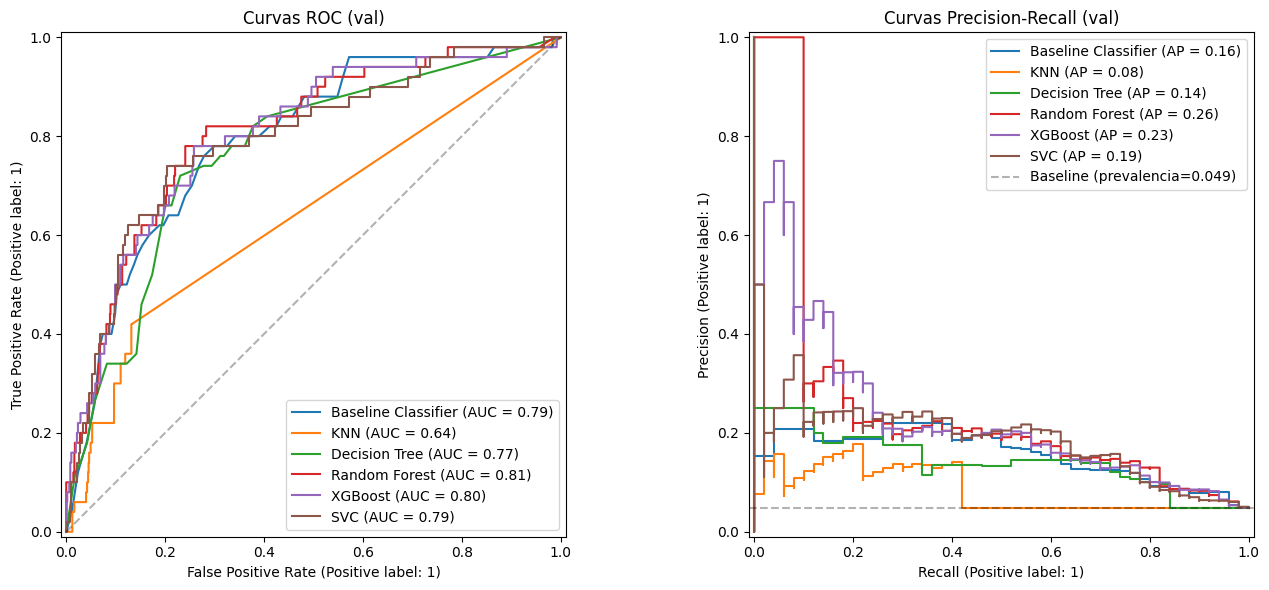

In [222]:
fig, (ax_roc, ax_pr) = plt.subplots(1, 2, figsize=(14, 6))

# ROC
RocCurveDisplay.from_predictions(y_val, y_prob_baseline_val, name='Baseline Classifier', ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_knn_val,   name='KNN',              ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_dt_val,    name='Decision Tree',    ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_rf_val,    name='Random Forest',    ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_xgb_val,   name='XGBoost',          ax=ax_roc)
RocCurveDisplay.from_predictions(y_val, y_prob_svc_val,   name='SVC',              ax=ax_roc)
ax_roc.plot([0, 1], [0, 1], 'k--', alpha=0.3)
ax_roc.set_title('Curvas ROC (val)')

# Precision-Recall
PrecisionRecallDisplay.from_predictions(y_val, y_prob_baseline_val, name='Baseline Classifier', ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_knn_val,   name='KNN',              ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_dt_val,    name='Decision Tree',    ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_rf_val,    name='Random Forest',    ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_xgb_val,   name='XGBoost',          ax=ax_pr)
PrecisionRecallDisplay.from_predictions(y_val, y_prob_svc_val,   name='SVC',              ax=ax_pr)
prevalence = y_val.mean() if hasattr(y_val, 'mean') else np.mean(y_val)
ax_pr.axhline(prevalence, color='k', linestyle='--', alpha=0.3,
              label=f'Baseline (prevalencia={prevalence:.3f})')
ax_pr.legend(loc='upper right')
ax_pr.set_title('Curvas Precision-Recall (val)')

plt.tight_layout()
plt.show()

## Matrices de Confusión en val


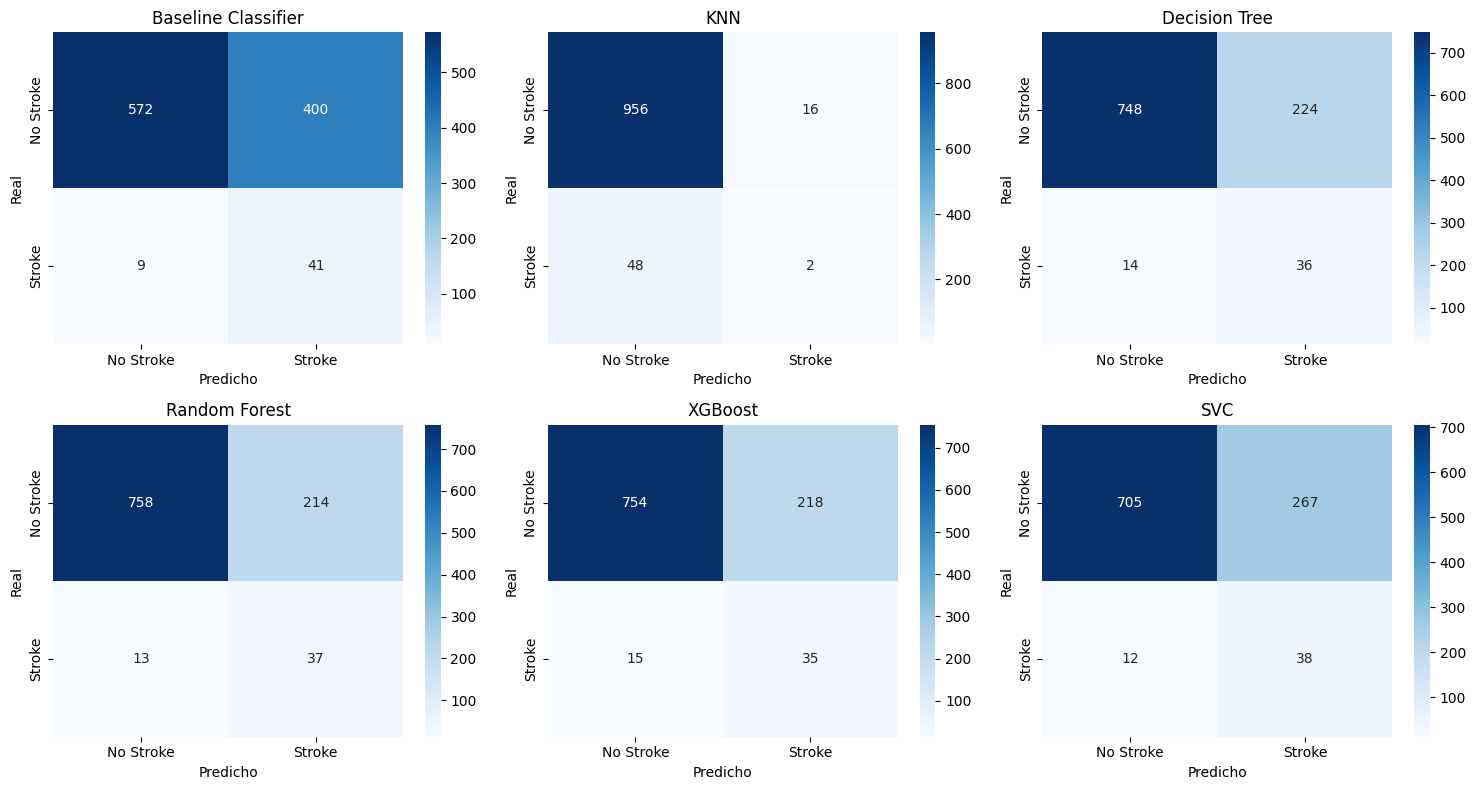

In [223]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, (y_pred, title) in zip(axes, [
    (y_pred_baseline_val, 'Baseline Classifier'),
    (y_pred_knn_val,   'KNN'),
    (y_pred_dt_val,    'Decision Tree'),
    (y_pred_rf_val,    'Random Forest'),
    (y_pred_xgb_val,   'XGBoost'),
    (y_pred_svc_val,   'SVC'),
]):
    sns.heatmap(confusion_matrix(y_val, y_pred), annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No Stroke', 'Stroke'],
                yticklabels=['No Stroke', 'Stroke'])
    ax.set_title(title)
    ax.set_xlabel('Predicho')
    ax.set_ylabel('Real')

plt.tight_layout()
plt.show()

KNN no ha rendido bien, algo esperable dado el desbalance.

A simple vista, Decision Tree, Random Forest, XGBoost y SVC muestran un desempeño bastante similar: los F2 en CV oscilan entre 0.38 y 0.42, con diferencias menores a 0.02 puntos.

Random Forest es el ganador por F2 en val (0.4102), con un balance razonable entre recall (0.74) y precisión (0.1474). La diferencia respecto a Decision Tree (F2=0.39) no es radical, lo que sugiere que un árbol simple ya captura bien la estructura del problema sin necesidad de ensambles.

SVC tiene el recall más alto (0.76) pero la precisión más baja, generando más falsos positivos. XGBoost tiene el recall más bajo de los cuatro (0.70), es decir, se pierde más casos reales de stroke (falsos negativos), aunque en términos absolutos la diferencia es pequeña dado el tamaño reducido de la clase positiva.

A pesar de que Decision Trees y Random Forest son casi iguales, se elige el modelo que menores falsos negativos tiene, además de que tiene mejor precisión.

### Mejor modelo: Random Forest

## Guardado de los modelos

Guardamos los 5 modelos tuneados y un `.pkl` con `best_params`, F-beta en CV, `val_results` (todos los modelos en val) y `test_results` (ganador en test).

In [224]:
os.makedirs('../models', exist_ok=True)

joblib.dump(baseline_model, '../models/baseline_classifier.pkl')
joblib.dump(knn_best,   '../models/knn_tuned.pkl')
joblib.dump(dt_best,    '../models/decision_tree_tuned.pkl')
joblib.dump(rf_best,    '../models/random_forest_tuned.pkl')
joblib.dump(xgb_best,   '../models/xgboost_tuned.pkl')
joblib.dump(svc_best,   '../models/svc_tuned.pkl')
print('Modelos guardados en ../models/')

feature_names = list(X_train.columns) if hasattr(X_train, 'columns') else None

joblib.dump({
    'best_params': {
        'Baseline Classifier': {'threshold': baseline_model.threshold},
        'KNN':              knn_study.best_params,
        'Decision Tree':    dt_study.best_params,
        'Random Forest':    rf_study.best_params,
        'XGBoost':          xgb_study.best_params,
        'SVC':              svc_study.best_params,
    },
    'cv_best_fbeta': {
        'Baseline Classifier': None,
        'KNN':              knn_study.best_value,
        'Decision Tree':    dt_study.best_value,
        'Random Forest':    rf_study.best_value,
        'XGBoost':          xgb_study.best_value,
        'SVC':              svc_study.best_value,
    },
    'beta':            BETA,
    'metric_name':     METRIC_NAME,
    'val_results':     val_df,
    'best_model_name': best_model_name,
    'feature_names':   feature_names,
}, '../data/tuning_results.pkl')

print(f'\nResumen guardado en ../data/tuning_results.pkl')
print(f'Mejor modelo por {METRIC_NAME} en val: {best_model_name} -> '
      f'{METRIC_NAME}(val)={val_df.loc[best_model_name, METRIC_NAME]:.4f}')

Modelos guardados en ../models/

Resumen guardado en ../data/tuning_results.pkl
Mejor modelo por F2 en val: Random Forest -> F2(val)=0.4102


Ahora veamos si podemos mejorar el rendimiento utilizando técnicas de ensamble en el notebook `03_ensamble` con los tres mejores modelos obtenidos aqui